Step 1 — Load the dataset

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv("../data/raw/Mental_health.csv")

# Display the first 5 rows
df.head()

,subject_id,sex,screen_time_index,est_leisure_screen_hours,sleep_quality_index,avg_sleep_hours,midsleep_weekend_hours,social_jetlag_hours,bdi_total,depressed
0,1,Boy,3.333,4.64,2.25,8.36,4.58,1.92,6,0
1,2,Girl,3.333,4.07,2.50,7.31,5.42,2.25,7,0
2,3,Boy,3.333,4.07,2.00,8.75,5.50,2.62,27,1
3,4,Boy,4.333,6.07,1.50,8.17,6.62,3.96,22,1
4,5,Boy,1.667,0.50,2.50,8.88,4.12,1.79,3,0


Step 2 — Find out exactly what variables we have

In [2]:
# Check the size of the dataset
print("Dataset shape:", df.shape)

# Show all column names
print("\nColumn names:")
print(df.columns.tolist())

# Check data types
print("\nData types:")
print(df.dtypes)

Dataset shape: (4810, 10)

Column names:
['subject_id', 'sex', 'screen_time_index', 'est_leisure_screen_hours', 'sleep_quality_index', 'avg_sleep_hours', 'midsleep_weekend_hours', 'social_jetlag_hours', 'bdi_total', 'depressed']

Data types:
subject_id                    int64
sex                             str
screen_time_index           float64
est_leisure_screen_hours    float64
sleep_quality_index         float64
avg_sleep_hours             float64
midsleep_weekend_hours      float64
social_jetlag_hours         float64
bdi_total                     int64
depressed                     int64
dtype: object


Step 3 — Get the basic descriptive statistics

In [3]:
# Descriptive statistics for numerical variables
df.describe()

,subject_id,screen_time_index,est_leisure_screen_hours,sleep_quality_index,avg_sleep_hours,midsleep_weekend_hours,social_jetlag_hours,bdi_total,depressed
count,4810.000000,4810.000000,4810.000000,4810.000000,4810.000000,4810.000000,4810.000000,4810.000000,4810.000000
mean,2405.500000,3.219097,3.958299,1.901611,7.689067,5.570553,2.400200,7.271518,0.163617
std,1388.671727,1.026348,2.387289,0.851176,1.270213,1.415505,1.137931,7.703156,0.369967
min,1.000000,1.000000,0.500000,1.000000,1.360000,1.670000,-3.030000,0.000000,0.000000
25%,1203.250000,2.333000,2.070000,1.250000,7.050000,4.540000,1.580000,2.000000,0.000000
50%,2405.500000,3.000000,3.500000,1.750000,7.870000,5.420000,2.290000,5.000000,0.000000
75%,3607.750000,4.000000,5.500000,2.250000,8.540000,6.500000,3.120000,10.000000,0.000000
max,4810.000000,6.000000,10.000000,6.000000,12.210000,10.500000,6.960000,51.000000,1.000000


Step 4 — Check missing values and categorical counts

In [4]:
# Check for missing values
print("Missing values:")
print(df.isnull().sum())

# Check the number of boys and girls
print("\nSex distribution:")
print(df["sex"].value_counts())

# Check depression classification
print("\nDepression classification:")
print(df["depressed"].value_counts())

# Show depression classification as percentages
print("\nDepression classification (%):")
print(df["depressed"].value_counts(normalize=True) * 100)

Missing values:
subject_id                  0
sex                         0
screen_time_index           0
est_leisure_screen_hours    0
sleep_quality_index         0
avg_sleep_hours             0
midsleep_weekend_hours      0
social_jetlag_hours         0
bdi_total                   0
depressed                   0
dtype: int64

Sex distribution:
sex
Boy     2446
Girl    2364
Name: count, dtype: int64

Depression classification:
depressed
0    4023
1     787
Name: count, dtype: int64

Depression classification (%):
depressed
0    83.638254
1    16.361746
Name: proportion, dtype: float64


Step 5 — First plot: depression prevalence

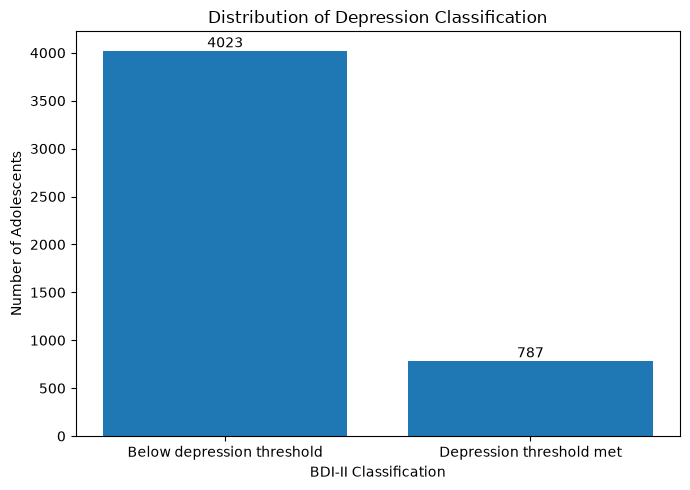

In [5]:
# Count adolescents in each depression category
depression_counts = df["depressed"].value_counts().sort_index()

# Create bar chart
plt.figure(figsize=(7, 5))

bars = plt.bar(
    ["Below depression threshold", "Depression threshold met"],
    depression_counts.values
)

plt.title("Distribution of Depression Classification")
plt.xlabel("BDI-II Classification")
plt.ylabel("Number of Adolescents")

# Add participant counts above bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height)}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

Step 6 — Screen time and depression status

In [6]:
# Calculate descriptive statistics for leisure screen time
# separately for each depression group

screen_time_by_group = df.groupby("depressed")["est_leisure_screen_hours"].agg(
    ["count", "mean", "median", "std"]
)

screen_time_by_group

,count,mean,median,std
depressed,,,,
0,4023,3.888422,3.50,2.369205
1,787,4.315502,4.07,2.448228


NOTES:

Adolescents who met the depression threshold reported somewhat higher average leisure screen time than those below the threshold (4.32 vs. 3.89 hours).

The adolescents who met the depression threshold reported about 0.43 more hours of leisure screen time on average — roughly 26 minutes more per day.

Step 7 — Visualise this difference

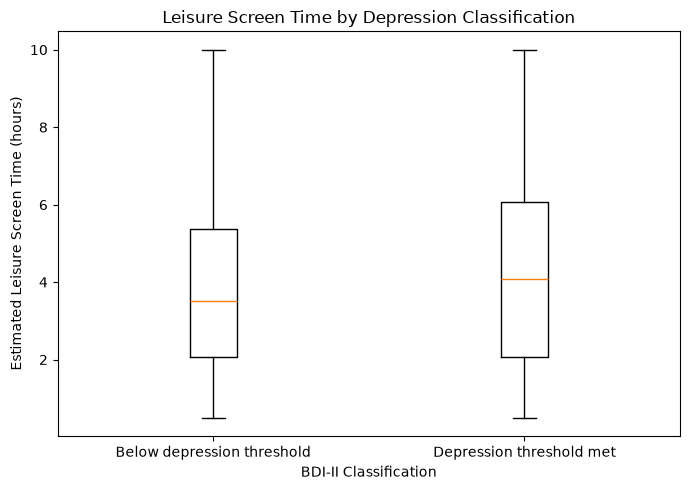

In [7]:
# Separate leisure screen time for the two groups
below_threshold = df[df["depressed"] == 0]["est_leisure_screen_hours"]
threshold_met = df[df["depressed"] == 1]["est_leisure_screen_hours"]

# Create boxplot
plt.figure(figsize=(7, 5))

plt.boxplot(
    [below_threshold, threshold_met],
    tick_labels=["Below depression threshold", "Depression threshold met"]
)

plt.title("Leisure Screen Time by Depression Classification")
plt.xlabel("BDI-II Classification")
plt.ylabel("Estimated Leisure Screen Time (hours)")

plt.tight_layout()
plt.show()

NOTES:

Each box represents the distribution of reported leisure screen time for one group.

The line inside each box is the median:

- Below depression threshold: 3.50 hours
- Depression threshold met: 4.07 hours

--> So the orange line being higher on the right visually shows that adolescents meeting the depression threshold tended to report more leisure screen time.

The boxes overlap quite substantially which tells us that screen time doesn't cleanly separate depressed and non-depressed adolescents. Plenty of people with similar amounts of screen time appear in both groups.

INITIAL FINDING:

Adolescents meeting the depression threshold reported somewhat higher leisure screen time, but there was considerable overlap between the two groups.

Step 8 — Now investigate sleep quality

In [8]:
# Calculate descriptive statistics for sleep quality
# separately for each depression group

sleep_quality_by_group = df.groupby("depressed")["sleep_quality_index"].agg(
    ["count", "mean", "median", "std"]
)

sleep_quality_by_group

,count,mean,median,std
depressed,,,,
0,4023,1.784241,1.50,0.752085
1,787,2.501588,2.25,1.052342


NOTES:

The dataset contains 4,023 adolescents below the depression threshold and 787 adolescents who meet the depression threshold. Adolescents below the depression threshold have a mean Sleep Quality Index score of 1.78 and a median of 1.50.


Adolescents meeting the depression threshold have a higher mean Sleep Quality Index score of 2.50 and a median of 2.25.


Higher Sleep Quality Index scores indicate more frequent sleep-disturbance symptoms, meaning poorer/more disturbed sleep.

Therefore, the group meeting the depression threshold reports poorer sleep quality on average.


The standard deviation is also larger in the depression-threshold group (1.05 vs. 0.75), suggesting greater variation in sleep-quality scores within this group.


These are descriptive results only. They show a difference between the groups but do not establish that poor sleep causes depression or that sleep quality can predict depression on its own.

INITIAL FINDING:

Adolescents meeting the depression threshold reported more frequent sleep-disturbance symptoms, with a higher mean Sleep Quality Index score (M = 2.50, SD = 1.05) than adolescents below the depression threshold (M = 1.78, SD = 0.75).

This suggests an association between poorer sleep quality and depression classification that warrants further investigation in the predictive analysis.

Step 9 — Visualise sleep quality by depression classification

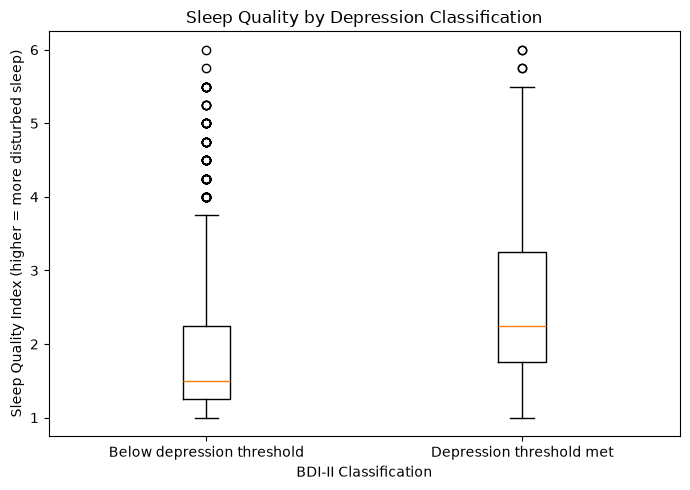

In [9]:
# Separate sleep quality scores for the two depression groups
sleep_below_threshold = df[df["depressed"] == 0]["sleep_quality_index"]
sleep_threshold_met = df[df["depressed"] == 1]["sleep_quality_index"]

# Create boxplot
plt.figure(figsize=(7, 5))

plt.boxplot(
    [sleep_below_threshold, sleep_threshold_met],
    tick_labels=["Below depression threshold", "Depression threshold met"]
)

plt.title("Sleep Quality by Depression Classification")
plt.xlabel("BDI-II Classification")
plt.ylabel("Sleep Quality Index (higher = more disturbed sleep)")

plt.tight_layout()
plt.show()

NOTES:

The line inside each box shows the middle (median) sleep quality score for each group.

The depression threshold group has a higher middle score than the below-threshold group.

Higher scores mean more disturbed/poorer sleep, so the depression threshold group generally reported worse sleep.


The taller box on the right shows that sleep quality scores varied more among adolescents who met the depression threshold.

The two groups still overlap. This means that poor sleep is not only seen in adolescents who meet the depression threshold.


The small circles represent unusually high sleep quality scores compared with most people in that group. These are outliers.

An outlier is not necessarily an error. In this case, it may simply represent an adolescent who reported poor sleep but did not meet the depression threshold.

INITIAL FINDING:

Adolescents who met the depression threshold generally reported poorer sleep quality than those below the threshold.

Although the two groups overlap, the depression-threshold group had noticeably higher sleep-disturbance scores overall, suggesting a relationship between poorer sleep quality and depression status.

Step 10 — Sleep quality and BDI-II score

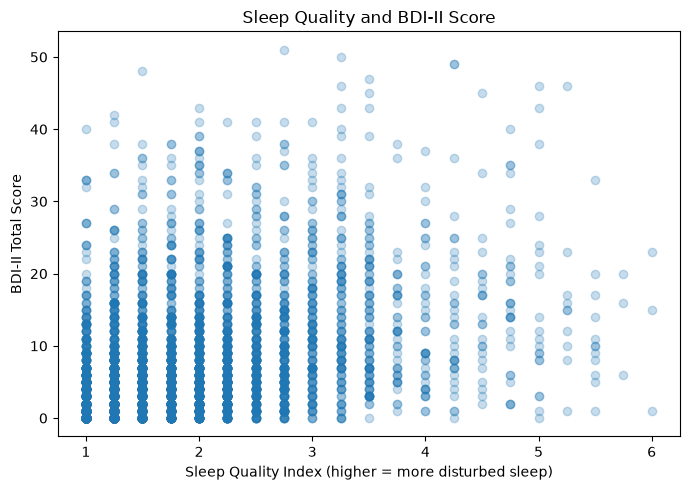

In [10]:
# Create a scatter plot of sleep quality and BDI-II score

plt.figure(figsize=(7, 5))

plt.scatter(
    df["sleep_quality_index"],
    df["bdi_total"],
    alpha=0.25
)

plt.title("Sleep Quality and BDI-II Score")
plt.xlabel("Sleep Quality Index (higher = more disturbed sleep)")
plt.ylabel("BDI-II Total Score")

plt.tight_layout()
plt.show()

NOTES:

Each dot represents one adolescent.

Moving from left to right means the adolescent reported more disturbed sleep.

Moving upwards means the adolescent had a higher BDI-II depression score.

The dots are spread out, meaning adolescents with similar sleep quality scores can have very different BDI-II scores.

There appear to be more higher BDI-II scores as sleep disturbance increases, but the relationship is not completely clear from the graph alone.

--> BDI-II = Beck Depression Inventory-II
--> It is a measure of the severity of depressive symptoms

--> Higher BDI-II total score = more severe depressive symptoms.

The vertical lines of dots occur because many adolescents have the same or similar Sleep Quality Index scores.



Step 11 — Calculate the correlation

In [11]:
# Calculate the correlation between Sleep Quality Index and BDI-II score

sleep_bdi_correlation = df["sleep_quality_index"].corr(df["bdi_total"])

print("Correlation between Sleep Quality Index and BDI-II score:")
print(round(sleep_bdi_correlation, 3))

Correlation between Sleep Quality Index and BDI-II score:
0.381


NOTES:

The correlation is 0.381.

A positive correlation means that the two variables tend to increase together.

In this case, adolescents with higher Sleep Quality Index scores (more disturbed sleep) tended to have higher BDI-II scores (more severe depressive symptoms).

The correlation is not close to 1, so the relationship is not perfect. Sleep quality does not explain everyone's BDI-II score.

This supports what we saw in the scatter plot: there is a general relationship, but there is also a lot of variation between adolescents.

Correlation shows that two variables are related, but it does not mean that one causes the other.

INITIAL FINDING:

There was a moderate positive correlation between sleep disturbance and depressive symptom severity (r = 0.381).

Adolescents reporting more disturbed sleep tended to have higher BDI-II scores.

Step 12 — Screen time and BDI-II score

--> Do adolescents who report more leisure screen time also tend to have higher BDI-II scores?

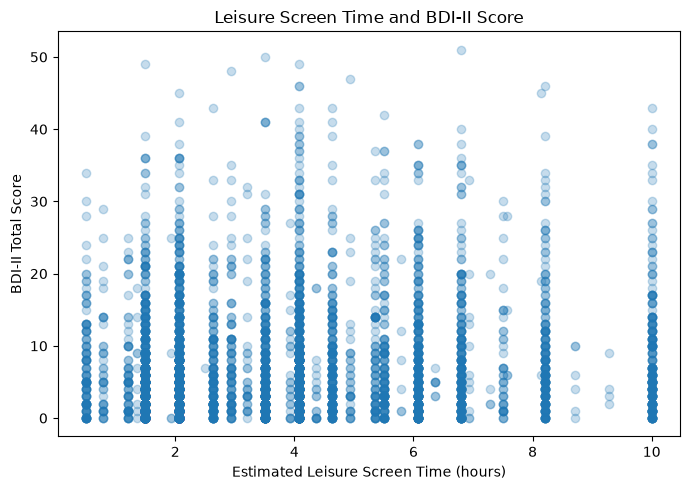

In [12]:
# Create a scatter plot of leisure screen time and BDI-II score

plt.figure(figsize=(7, 5))

plt.scatter(
    df["est_leisure_screen_hours"],
    df["bdi_total"],
    alpha=0.25
)

plt.title("Leisure Screen Time and BDI-II Score")
plt.xlabel("Estimated Leisure Screen Time (hours)")
plt.ylabel("BDI-II Total Score")

plt.tight_layout()
plt.show()

NOTES:

Each dot represents one adolescent.

Moving from left to right means more estimated leisure screen time.

Moving upwards means a higher BDI-II score and therefore more severe depressive symptoms.

The dots are very spread out. Adolescents reporting similar amounts of screen time can have very different BDI-II scores.

There is no strong or obvious pattern from the graph alone.

The vertical lines of dots occur because many adolescents have the same or similar estimated screen time values.

We need to calculate the correlation to see whether there is a relationship that is difficult to see from the graph.

Step 13 — Calculate the correlation

In [13]:
# Calculate the correlation between leisure screen time and BDI-II score

screen_bdi_correlation = df["est_leisure_screen_hours"].corr(df["bdi_total"])

print("Correlation between leisure screen time and BDI-II score:")
print(round(screen_bdi_correlation, 3))

Correlation between leisure screen time and BDI-II score:
0.107


NOTES:

The correlation is 0.107.

This is a weak positive correlation.

This means that adolescents who reported more leisure screen time tended to have slightly higher BDI-II scores, but the relationship is small.

This matches the scatter plot, where there was no strong pattern and adolescents with similar amounts of screen time had very different BDI-II scores.

The relationship between leisure screen time and BDI-II score is weaker than the relationship we found between sleep quality and BDI-II score (0.381).

Correlation shows a relationship between variables, but it does not mean that one causes the other.

INITIAL FINDING:

There was a weak positive correlation between estimated leisure screen time and depressive symptom severity (r = 0.107).

Adolescents reporting more leisure screen time tended to have slightly higher BDI-II scores, although the relationship was weak.

Step 14 — Screen time and sleep quality

--> Do adolescents who report more leisure screen time also tend to report more disturbed sleep?

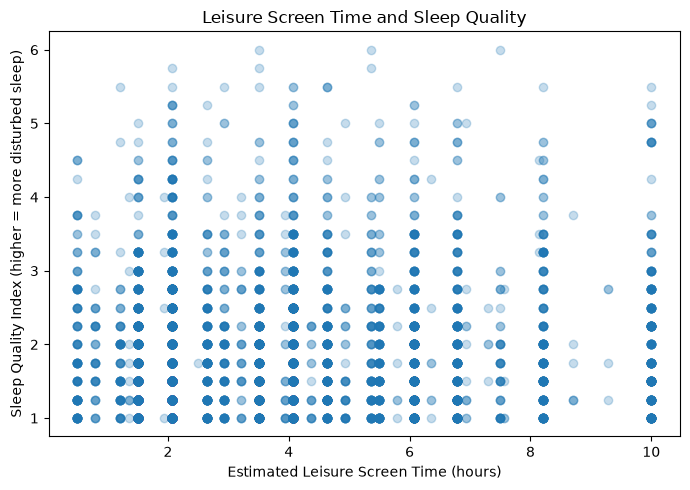

In [14]:
# Create a scatter plot of leisure screen time and sleep quality

plt.figure(figsize=(7, 5))

plt.scatter(
    df["est_leisure_screen_hours"],
    df["sleep_quality_index"],
    alpha=0.25
)

plt.title("Leisure Screen Time and Sleep Quality")
plt.xlabel("Estimated Leisure Screen Time (hours)")
plt.ylabel("Sleep Quality Index (higher = more disturbed sleep)")

plt.tight_layout()
plt.show()

NOTES:

Each dot represents one adolescent.

Moving from left to right means more estimated leisure screen time.

Moving upwards means more disturbed/poorer sleep.

The dots are spread out, so there is no strong or obvious relationship between screen time and sleep quality from the graph alone.

Adolescents reporting similar amounts of screen time can have very different sleep quality scores.

We need to calculate the correlation to see whether there is a relationship that is difficult to see from the graph.

Step 15 — Calculate the correlation

In [15]:
# Calculate the correlation between leisure screen time and sleep quality

screen_sleep_correlation = df["est_leisure_screen_hours"].corr(
    df["sleep_quality_index"]
)

print("Correlation between leisure screen time and Sleep Quality Index:")
print(round(screen_sleep_correlation, 3))

Correlation between leisure screen time and Sleep Quality Index:
0.072


NOTES:

The correlation is 0.072.

This is a very weak positive correlation.

This means that adolescents who reported more leisure screen time tended to report slightly more disturbed sleep, but the relationship is very small.

This matches the scatter plot, where there was no clear pattern between screen time and sleep quality.

Overall, screen time and sleep quality appear to be only weakly related in this dataset.

Correlation does not mean that one variable causes the other.

INITIAL FINDING:

There was a very weak positive correlation between estimated leisure screen time and sleep disturbance (r = 0.072).

This suggests that leisure screen time and sleep quality have little linear relationship in this dataset.

Step 16 — Create a correlation heatmap

--> Explore correlations between the main numerical variables

In [16]:
import seaborn as sns

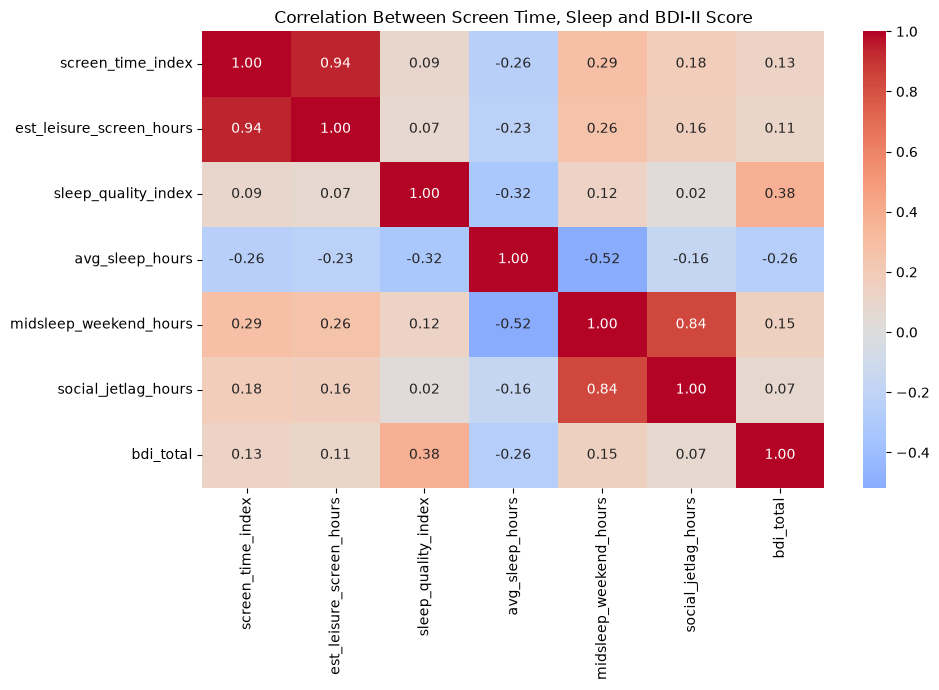

In [17]:
# Select the main numerical variables

correlation_variables = df[
    [
        "screen_time_index",
        "est_leisure_screen_hours",
        "sleep_quality_index",
        "avg_sleep_hours",
        "midsleep_weekend_hours",
        "social_jetlag_hours",
        "bdi_total"
    ]
]

# Calculate the correlations
correlation_matrix = correlation_variables.corr()

# Create the heatmap
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Between Screen Time, Sleep and BDI-II Score")

plt.tight_layout()
plt.show()

NOTES:

Each square shows the correlation between two variables.

Positive numbers mean that the two variables tend to increase together.

Negative numbers mean that as one variable increases, the other tends to decrease.

Numbers closer to 1 or -1 show stronger relationships, while numbers closer to 0 show weaker relationships.

The 1.00 values are where each variable is compared with itself, so these can be ignored.


- Sleep disturbance and BDI-II score have a moderate positive relationship (0.38). More disturbed sleep tends to be associated with higher depressive symptom scores.


- Average sleep hours and BDI-II score have a negative relationship (-0.26). This means that adolescents who sleep for fewer hours tend to have higher depressive symptom scores.


- Leisure screen time and BDI-II score have only a weak positive relationship (0.11).


- Screen Time Index and estimated leisure screen hours are very strongly related (0.94). This suggests that they are measuring very similar aspects of screen time.


- Weekend midsleep and social jetlag are also very strongly related (0.84).


- Overall, sleep-related measures show clearer relationships with BDI-II scores than the screen-time measures do.

INITIAL FINDING:

The correlation heatmap showed that sleep disturbance had the clearest positive relationship with BDI-II score (r = 0.38), while average sleep duration had a negative relationship with BDI-II score (r = -0.26).

The relationship between leisure screen time and BDI-II score was much weaker (r = 0.11).

The two screen-time measures were very strongly correlated with each other (r = 0.94), suggesting that they contain very similar information.

Step 17 — Investigate unusual average sleep-hour values

In [18]:
# Look more closely at average sleep hours

print("Average sleep hours summary:")
print(df["avg_sleep_hours"].describe())

print("\nNumber reporting less than 4 hours average sleep:")
print((df["avg_sleep_hours"] < 4).sum())

print("\nNumber reporting more than 10 hours average sleep:")
print((df["avg_sleep_hours"] > 10).sum())

Average sleep hours summary:
count    4810.000000
mean        7.689067
std         1.270213
min         1.360000
25%         7.050000
50%         7.870000
75%         8.540000
max        12.210000
Name: avg_sleep_hours, dtype: float64

Number reporting less than 4 hours average sleep:
68

Number reporting more than 10 hours average sleep:
50


NOTES:

Average sleep ranges from 1.36 to 12.21 hours.

The average is 7.69 hours, and the middle (median) value is 7.87 hours.

68 adolescents have average sleep values below 4 hours.

50 adolescents have average sleep values above 10 hours.

This shows that there are unusual values at both the low and high ends, although they make up only a small part of the dataset.

In [19]:
# Show the 10 lowest average sleep-hour values

lowest_sleep = df.nsmallest(10, "avg_sleep_hours")[
    [
        "subject_id",
        "sex",
        "avg_sleep_hours",
        "sleep_quality_index",
        "bdi_total",
        "depressed"
    ]
]

lowest_sleep

,subject_id,sex,avg_sleep_hours,sleep_quality_index,bdi_total,depressed
693,694,Girl,1.36,3.25,46,1
4270,4271,Girl,1.77,4.25,25,1
4556,4557,Boy,2.05,2.75,28,1
4357,4358,Girl,2.07,2.50,41,1
4098,4099,Girl,2.36,2.50,9,0
987,988,Girl,2.48,2.25,11,0
2707,2708,Girl,2.49,5.00,11,0
2129,2130,Boy,2.64,2.00,7,0
4349,4350,Girl,2.64,3.00,13,0
3181,3182,Girl,2.68,2.25,31,1


NOTES:

The lowest average sleep value is 1.36 hours.

This value is not completely isolated. Other very low values include 1.77, 2.05, 2.07 and 2.36 hours.

This suggests that there is a small group of adolescents with unusually low average sleep values, rather than just one unusual value.

Some of these adolescents meet the depression threshold and some do not.

We should not assume these values are errors or remove them until we understand how average sleep hours were calculated in the original dataset.

Step 18 – Visualise the distribution of average sleep duration

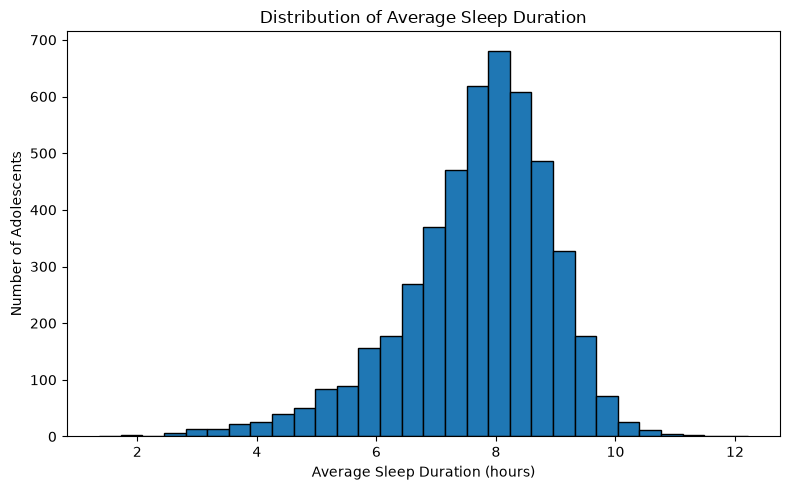

In [20]:
# Create a histogram of average sleep duration

plt.figure(figsize=(8, 5))

plt.hist(
    df["avg_sleep_hours"],
    bins=30,
    edgecolor="black"
)

plt.title("Distribution of Average Sleep Duration")
plt.xlabel("Average Sleep Duration (hours)")
plt.ylabel("Number of Adolescents")

plt.tight_layout()
plt.show()

NOTES:

Most adolescents have an average sleep duration of around 7–9 hours per night.

The highest part of the graph is around 8 hours, meaning this is where many of the adolescents are concentrated.

There are fewer adolescents at the very low and very high ends of the graph.

Very low sleep durations, such as 1–4 hours, are unusual compared with the rest of the dataset.

Very high sleep durations above 10 hours are also relatively uncommon.

The values gradually become less common towards both ends rather than appearing as completely separate groups.

This shows that the unusual sleep values are part of the ends, or "tails", of the distribution.

However, because some values fall outside the range reported in the original study, they should still be flagged for further investigation rather than automatically removed.